In [9]:
import matplotlib
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import blimpy as bl 
import glob
%matplotlib inline

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

In [2]:
turboseti_snr_list = [1, 1.5, 2, 5, 8, 10, 15, 20, 25, 30, 35, 40, 150]
turboseti_snr_list = [1,1.2,1.3,1.4,1.5, 2, 5, 8, 10, 15.0, 20, 25.0, 30, 35.0, 40]

turboseti_average_factor_vec = []
turboseti_low_drift_factor_vec = []

tsnrs = []
fps = []
tps = []
fns = []
tprecisions = []
trecalls = []

a = np.load('/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz_injections.npy')
a = np.load('/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz_snr1_1000_injections.npy')
pfreqs = a[0]
drifts = a[1]
snrvec = a[2]
widths = a[3]

f_errors = []
d_errors = []

for snr in turboseti_snr_list:

    recorded_snrvec = []
    expected = [] # 1 where SNR should be detectable, 0 where not

    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/seticore_output/L-band/spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000.10_seticore.dat')
    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/quick_test/widths_to_10_blc73_guppi_58832_16209_MESSIER031_0057.rawspec.0000.10_seticore.dat')
    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_many_widths_many_drifts.20_seticore.dat')
    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_unresolved_evenmorespace.20_seticore.dat')
    #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz.{snr}_seticore.dat')
    dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz_snr1_1000.{snr}_seticore.dat')

    dat = dats[0]
    #print(dat)

    tsnrs.append(snr)

    df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                'Full_number_of_hits'], skiprows=9)
    ff = df['freq_start'].values
    dd = df['Drift_Rate'].values
    ss = df['SNR'].values
    n_inj = len(pfreqs)

    for i in range(n_inj):
        pf = pfreqs[i]
        pdiffvec = ff - pf
        d = drifts[i]
        if snrvec[i] < snr:
            expected.append(0)
            recorded_snrvec.append(np.nan)
            continue
        else:
            expected.append(1)
        best_candidate_idxs = np.where(np.abs(pdiffvec)*1000 < 1)[0]
        #print('SNR', str(snr), 'best idx', str(best_candidate_idxs))
        best_candidate_drifts = np.concatenate((dd[best_candidate_idxs], [100])) # add 100 as a fix for len-0 case
        if (np.min(np.abs(pdiffvec))*1000 < 1) & (np.min(np.abs(best_candidate_drifts-d)) < 0.5): # permit accuracy to within 1 kHz
            #print(best_candidate_drifts)
            f_errors.append(ff[np.argmin(np.abs(pdiffvec))]-pf)
            d_errors.append(best_candidate_drifts[np.argmin(np.abs(best_candidate_drifts-d))]-d)
            #if i < 5:
            #    print(f'Freq check: {ff[np.argmin(np.abs(pdiffvec))]} versus injected {pf}')
            #    print(f'Drift check: {best_candidate_drifts[np.argmin(np.abs(best_candidate_drifts-d))]} versus injected {d}')
            true_idx = best_candidate_idxs[np.argmin(np.abs(best_candidate_drifts-d))]
            recorded_snr = ss[true_idx]
            recorded_snrvec.append(recorded_snr)
        else:
            recorded_snrvec.append(np.nan)
        #break

    expected = np.array(expected)
    recorded_snrvec_where_expected = np.array(recorded_snrvec)[np.where(expected == 1)[0]]

    tp = len(np.where(np.isnan(recorded_snrvec_where_expected)==False)[0])
    fn = len(np.where(np.isnan(recorded_snrvec_where_expected)==True)[0])
    fp = len(ff) - tp

    print(f'TP: {tp}')
    print(f'FN: {fn}')
    print(f'FP: {fp}')

    precision = tp/(tp+fp)
    recall = tp/(tp+fn)
    tprecisions.append(precision)
    trecalls.append(recall)
    
    #break



TP: 1442
FN: 23
FP: 6479
TP: 1439
FN: 25
FP: 5613
TP: 1438
FN: 26
FP: 2161
TP: 1438
FN: 26
FP: 333
TP: 1437
FN: 27
FP: 37
TP: 1433
FN: 29
FP: 0
TP: 1384
FN: 73
FP: 0
TP: 1334
FN: 120
FP: 0
TP: 1303
FN: 149
FP: 0
TP: 1230
FN: 215
FP: 0
TP: 1160
FN: 280
FP: 0
TP: 1088
FN: 349
FP: 0
TP: 1021
FN: 409
FP: 0
TP: 952
FN: 472
FP: 0
TP: 870
FN: 548
FP: 0


In [3]:
bliss_snr_list = [1, 1.5, 2, 5, 8, 10, 15, 20, 25, 30, 35, 40, 150]
bliss_snr_list = [10,15,20,25,30,35,40,50,75,100,150]
bliss_l1_list = [10,20,30,40,50]

bsnrs = []
bl1s = []
fps = []
tps = []
fns = []
bprecisions = []
brecalls = []

a = np.load('/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz_injections.npy')
a = np.load('/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz_snr1_1000_injections.npy')
pfreqs = a[0]
drifts = a[1]
snrvec = a[2]
widths = a[3]

f_errors = []
d_errors = []

for snr in bliss_snr_list:
    for l1 in bliss_l1_list:

        recorded_snrvec = []
        expected = [] # 1 where SNR should be detectable, 0 where not

        #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/seticore_output/L-band/spliced_blc4041424344454647_guppi_58885_63646_MESSIER081_0057.rawspec.0000.10_seticore.dat')
        #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/quick_test/widths_to_10_blc73_guppi_58832_16209_MESSIER031_0057.rawspec.0000.10_seticore.dat')
        #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_many_widths_many_drifts.20_seticore.dat')
        #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/Voyager_injections_unresolved_evenmorespace.20_seticore.dat')
        #dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz.{snr}_seticore.dat')
        dats = glob.glob(f'/datax/scratch/benjb/bliss_LSCX_test/synthetic_unresolved_vardrift1_32kHz_snr1_1000_nosig_nosk_SNR_{snr}_L1_{l1}.dat')

        dat = dats[0]
        #print(dat)

        bsnrs.append(snr)
        bl1s.append(l1)

        df = pd.read_table(dat, sep='\s+', names=['Top_Hit_#','Drift_Rate','SNR','Uncorrected_Frequency','Corrected_Frequency',
                                                    'Index', 'freq_start', 'freq_end', 'SEFD', 'SEFD_freq', 'Coarse_Channel_Number', 
                                                    'Full_number_of_hits'], skiprows=9)
        ff = df['freq_start'].values
        dd = df['Drift_Rate'].values
        ss = df['SNR'].values
        n_inj = len(pfreqs)

        for i in range(n_inj):
            pf = pfreqs[i]
            pdiffvec = ff - pf
            d = drifts[i]
            if snrvec[i] < snr:
                expected.append(0)
                recorded_snrvec.append(np.nan)
                continue
            else:
                expected.append(1)
            best_candidate_idxs = np.where(np.abs(pdiffvec)*1000 < 1)[0]
            #print('SNR', str(snr), 'best idx', str(best_candidate_idxs))
            best_candidate_drifts = np.concatenate((dd[best_candidate_idxs], [100])) # add 100 as a fix for len-0 case
            if (np.min(np.abs(pdiffvec))*1000 < 1) & (np.min(np.abs(best_candidate_drifts-d)) < 0.5): # permit accuracy to within 1 kHz
                #print(best_candidate_drifts)
                f_errors.append(ff[np.argmin(np.abs(pdiffvec))]-pf)
                d_errors.append(best_candidate_drifts[np.argmin(np.abs(best_candidate_drifts-d))]-d)
                #if i < 5:
                #    print(f'Freq check: {ff[np.argmin(np.abs(pdiffvec))]} versus injected {pf}')
                #    print(f'Drift check: {best_candidate_drifts[np.argmin(np.abs(best_candidate_drifts-d))]} versus injected {d}')
                true_idx = best_candidate_idxs[np.argmin(np.abs(best_candidate_drifts-d))]
                recorded_snr = ss[true_idx]
                recorded_snrvec.append(recorded_snr)
            else:
                recorded_snrvec.append(np.nan)
            #break

        expected = np.array(expected)
        recorded_snrvec_where_expected = np.array(recorded_snrvec)[np.where(expected == 1)[0]]

        tp = len(np.where(np.isnan(recorded_snrvec_where_expected)==False)[0])
        fn = len(np.where(np.isnan(recorded_snrvec_where_expected)==True)[0])
        fp = len(ff) - tp

        print(f'TP: {tp}')
        print(f'FN: {fn}')
        print(f'FP: {fp}')

        precision = tp/(tp+fp)
        recall = tp/(tp+fn)
        bprecisions.append(precision)
        brecalls.append(recall)
        
        #break



TP: 1432
FN: 20
FP: 481
TP: 1432
FN: 20
FP: 58
TP: 1432
FN: 20
FP: 10
TP: 1432
FN: 20
FP: 6
TP: 1432
FN: 20
FP: 3
TP: 1427
FN: 18
FP: 357
TP: 1427
FN: 18
FP: 35
TP: 1427
FN: 18
FP: 6
TP: 1427
FN: 18
FP: 4
TP: 1427
FN: 18
FP: 2
TP: 1418
FN: 22
FP: 265
TP: 1418
FN: 22
FP: 22
TP: 1418
FN: 22
FP: 2
TP: 1418
FN: 22
FP: 2
TP: 1418
FN: 22
FP: 1
TP: 1413
FN: 24
FP: 192
TP: 1413
FN: 24
FP: 15
TP: 1413
FN: 24
FP: 5
TP: 1413
FN: 24
FP: 3
TP: 1413
FN: 24
FP: 2
TP: 1405
FN: 25
FP: 177
TP: 1405
FN: 25
FP: 16
TP: 1405
FN: 25
FP: 4
TP: 1405
FN: 25
FP: 1
TP: 1405
FN: 25
FP: 1
TP: 1389
FN: 35
FP: 150
TP: 1389
FN: 35
FP: 9
TP: 1389
FN: 35
FP: 3
TP: 1389
FN: 35
FP: 2
TP: 1389
FN: 35
FP: 2
TP: 1380
FN: 38
FP: 80
TP: 1380
FN: 38
FP: 7
TP: 1380
FN: 38
FP: 3
TP: 1380
FN: 38
FP: 2
TP: 1380
FN: 38
FP: 2
TP: 1355
FN: 44
FP: 18
TP: 1355
FN: 44
FP: 2
TP: 1355
FN: 44
FP: 2
TP: 1355
FN: 44
FP: 2
TP: 1355
FN: 44
FP: 2
TP: 1304
FN: 54
FP: 5
TP: 1304
FN: 54
FP: 5
TP: 1304
FN: 54
FP: 5
TP: 1304
FN: 54
FP: 5
TP: 1304
FN:

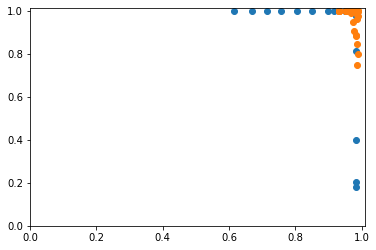

In [4]:
plt.scatter(trecalls, tprecisions)
plt.scatter(brecalls, bprecisions)
plt.xlim(0,1.01)
plt.ylim(0,1.01)
plt.show()

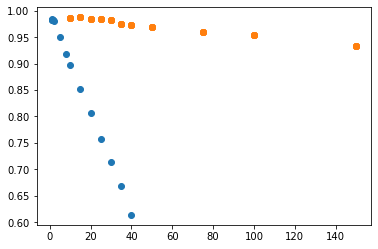

In [5]:
plt.scatter(tsnrs, trecalls)
plt.scatter(bsnrs, brecalls)
plt.show()

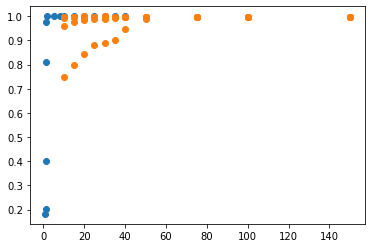

In [6]:
plt.scatter(tsnrs, tprecisions)
plt.scatter(bsnrs, bprecisions)
plt.show()

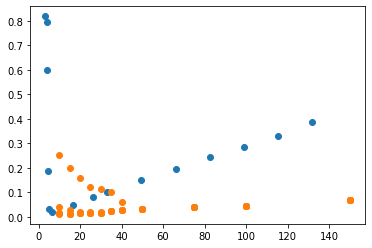

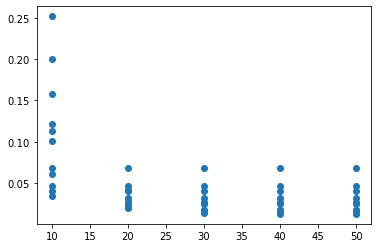

0.019835841313269542
0.012535125864429226
[0.25181453 0.04129132 0.01542134 0.0143922  0.01393185]
[0.20049944 0.02698676 0.0131416  0.01276652 0.01253513]


In [7]:
tdistances = np.sqrt((np.array(tprecisions)-1)**2 + (np.array(trecalls)-1)**2)
bdistances = np.sqrt((np.array(bprecisions)-1)**2 + (np.array(brecalls)-1)**2)

plt.scatter(np.array(tsnrs)*3.3, tdistances)
plt.scatter(bsnrs, bdistances)
#plt.xlim(0,40)
plt.show()

plt.scatter(bl1s, bdistances)
#plt.ylim(0,0.05)
plt.show()

print(np.min(tdistances))
print(np.min(bdistances))
print(bdistances[np.where(np.array(bsnrs) == 10)[0]])
print(bdistances[np.where(np.array(bsnrs) == 15)[0]])

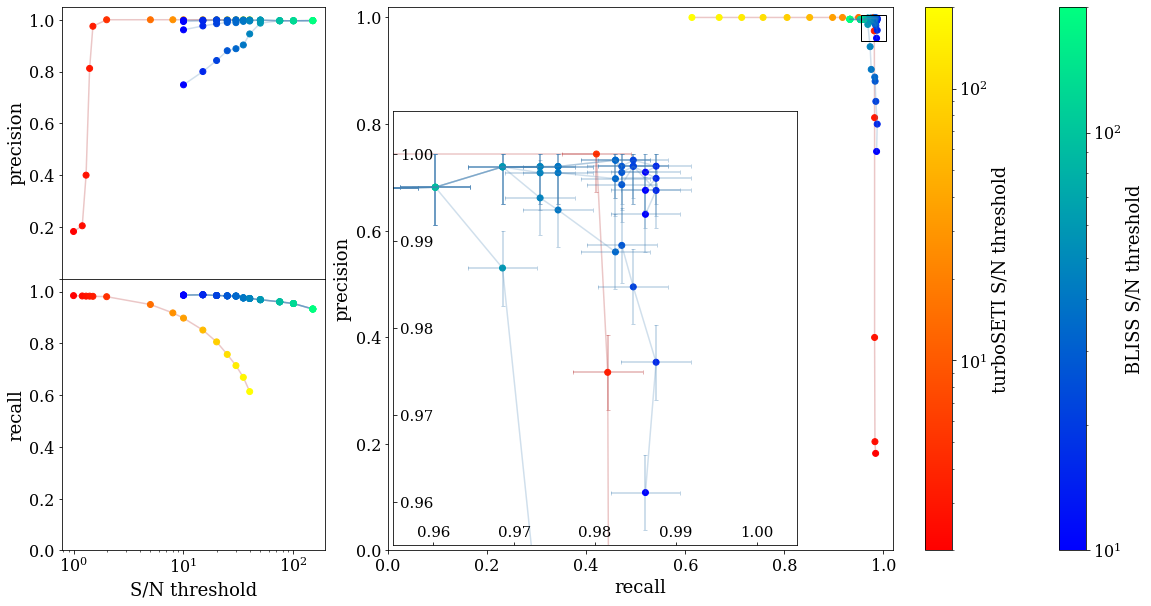

In [22]:
import matplotlib

bl_map = 'winter'
ts_map = 'autumn'
tsize = 18

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(20,10), gridspec_kw={'width_ratios': [1, 3]}, sharex=True)
gs = axs[0,1].get_gridspec()
# remove the underlying Axes
for ax in axs[:, -1]:
    ax.remove()
axbig = fig.add_subplot(gs[:, -1])

bl1s = np.array(bl1s)
for l1 in np.unique(bl1s):
    br = np.array(brecalls)[np.where(bl1s == l1)[0]]
    bp = np.array(bprecisions)[np.where(bl1s == l1)[0]]
    bs = np.array(bsnrs)[np.where(bl1s == l1)[0]]
    axbig.plot(br, bp, color='steelblue', alpha=0.25)
    axs[1,0].plot(bs, br, color='steelblue', alpha=0.25, zorder=0)
    axs[0,0].plot(bs, bp, color='steelblue', alpha=0.25, zorder=0)
axbig.plot(trecalls, tprecisions, color='firebrick', alpha=0.25, zorder=0)
axs[1,0].plot(tsnrs, trecalls, color='firebrick', alpha=0.25, zorder=0)
axs[0,0].plot(tsnrs, tprecisions, color='firebrick', alpha=0.25, zorder=0)

axbig.scatter(trecalls, tprecisions, c=tsnrs, cmap=ts_map, norm=matplotlib.colors.LogNorm(), zorder=1)
#axins2.scatter(trecalls, tprecisions, c=tsnrs, cmap=ts_map, norm=matplotlib.colors.LogNorm(), zorder=1)
axs[0,0].scatter(tsnrs, tprecisions, c=tsnrs, cmap=ts_map, norm=matplotlib.colors.LogNorm(), zorder=1)
axs[1,0].scatter(tsnrs, trecalls, c=tsnrs, cmap=ts_map, norm=matplotlib.colors.LogNorm(), zorder=1)
axbig.scatter(brecalls, bprecisions, c=bsnrs, cmap=bl_map, norm=matplotlib.colors.LogNorm(), zorder=1)
#axins2.scatter(brecalls, bprecisions, c=bsnrs, cmap=bl_map, norm=matplotlib.colors.LogNorm(), zorder=1)
axs[0,0].scatter(bsnrs, bprecisions, c=bsnrs, cmap=bl_map, norm=matplotlib.colors.LogNorm(), zorder=1)
axs[1,0].scatter(bsnrs, brecalls, c=bsnrs, cmap=bl_map, norm=matplotlib.colors.LogNorm(), zorder=1)

cbar1 = plt.colorbar(mappable=matplotlib.cm.ScalarMappable(norm=matplotlib.colors.LogNorm(vmin=10, vmax=200), cmap=bl_map))
cbar2 = plt.colorbar(mappable=matplotlib.cm.ScalarMappable(norm=matplotlib.colors.LogNorm(vmin=2, vmax=200), cmap=ts_map))
cbar1.set_label(label=r'BLISS S/N threshold', size=tsize)
cbar2.set_label(label=r'turboSETI S/N threshold', size=tsize)
#cbar.solids.set(alpha=1)

axbig.set_xlabel('recall', size=tsize)
axbig.set_ylabel('precision', size=tsize)
axbig.set_xlim(0,1.02)
axbig.set_ylim(0,1.02)

axs[1,0].set_ylim(0,1.05)
axs[0,0].set_ylim(0,1.05)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
axins2 = inset_axes(axbig, width="80%", height="80%", loc="lower left")
axins2.set_xlim(0.955,1.005)
axins2.set_ylim(0.955,1.005)
axins2.tick_params(axis="y",direction="in", pad=-40, labelsize=15)
axins2.tick_params(axis="x",direction="in", pad=-20, labelsize=15)

for l1 in np.unique(bl1s):
    br = np.array(brecalls)[np.where(bl1s == l1)[0]]
    bp = np.array(bprecisions)[np.where(bl1s == l1)[0]]
    bs = np.array(bsnrs)[np.where(bl1s == l1)[0]]
    axins2.plot(br, bp, color='steelblue', alpha=0.25)
axins2.plot(trecalls, tprecisions, color='firebrick', alpha=0.25, zorder=0)
yerrbliss = []
yerrturbo = []
for point in bprecisions:
    err = np.min((0.004311,1-point))
    yerrbliss.append([0.004311, err])
for point in tprecisions:
    err = np.min((0.004311,1-point))
    yerrturbo.append([0.004311, err])
axins2.errorbar(brecalls, bprecisions, np.transpose(yerrbliss), 0.004311, capsize=2, marker='', ls='', alpha=0.35, color='steelblue', zorder=1)
axins2.errorbar(trecalls, tprecisions, np.transpose(yerrturbo), 0.004311, capsize=2, marker='', ls='', alpha=0.35, color='firebrick', zorder=1)
#0.004311
axins2.scatter(trecalls, tprecisions, c=tsnrs, cmap=ts_map, norm=matplotlib.colors.LogNorm(), zorder=1)
axins2.scatter(brecalls, bprecisions, c=bsnrs, cmap=bl_map, norm=matplotlib.colors.LogNorm(), zorder=1)

axbig.indicate_inset_zoom(axins2, edgecolor="k", alpha=1)

axs[1,0].set_xlabel('S/N threshold', size=tsize)
axs[1,0].set_ylabel('recall', size=tsize)
axs[0,0].set_ylabel('precision', size=tsize)
axs[0,0].set_xscale('log')

#axs[0,0].grid(which='both')
#axs[1,0].grid(which='both')
#axbig.grid(which='major')
plt.subplots_adjust(hspace=0, wspace=0.12)

axs[0,0].tick_params(axis='both', which='major', labelsize=16)
axs[1,0].tick_params(axis='both', which='major', labelsize=16)
axbig.tick_params(axis='both', which='major', labelsize=16)
#axins2.tick_params(axis='both', which='major', labelsize=15)
cbar1.ax.tick_params(axis='both', which='major', labelsize=16)
cbar2.ax.tick_params(axis='both', which='major', labelsize=16)
axs[0,0].set_yticklabels([None, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.savefig('/datax/scratch/benjb/bliss_LSCX_test/Fig_BLISS_turboSETI_comparison_synthetic_PR_curve.pdf', bbox_inches='tight')

plt.show()

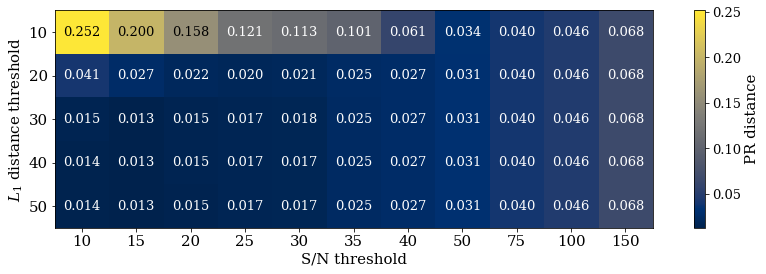

In [38]:
fig, ax = plt.subplots(figsize=(15,4))
plot_arr = np.transpose(bdistances.reshape((len(np.unique(bsnrs)), len(np.unique(bl1s)))))
s = ax.imshow(plot_arr, cmap='cividis', aspect=0.8)
ax.tick_params(axis='both', which='major', labelsize=15)
cbar = plt.colorbar(s)
#cbar.set_label(label=r'PR distance: [(1$-$P)$^{2}$+(1$-$R)$^{2}$]$^{1/2}$', size=14)
cbar.set_label(label=r'PR distance', size=15)
cbar.ax.tick_params(axis='both', which='major', labelsize=13)
#cbar.ax.set_ylim(np.min(plot_arr),np.max(plot_arr))
#cbar.set_ticks([0.15, 0.2, 0.25, 0.3])
#cbar.solids.set(alpha=1)
ax.set_xlabel('S/N threshold', size=15)
ax.set_ylabel(r'$L_1$ distance threshold', size=15)
ax.set_xticks(np.arange(len(np.unique(bsnrs))))
ax.set_xticklabels(np.unique(bsnrs), size=15)
ax.set_yticks(np.arange(len(np.unique(bl1s))))
ax.set_yticklabels(np.unique(bl1s), size=15)
# Loop over data dimensions and create text annotations.
for i in range(len(np.unique(bl1s))):
    for j in range(len(np.unique(bsnrs))):
        if plot_arr[i, j] > np.mean([plot_arr.min(), plot_arr.max()]):
            col = 'k'
        else:
            col = 'w'
        t = str(np.round(plot_arr[i, j],3))
        while len(t) < 5:
            t = t + '0'
        text = ax.text(j, i, t,
                       ha="center", va="center", color=col, size=13)
plt.savefig('/datax/scratch/benjb/bliss_LSCX_test/Fig_BLISS_synthetic_SNR_L1_PR_heatmap.pdf', bbox_inches='tight')
plt.show()